## Упражнение 02. Столбчатая диаграмма

In [2]:
import pandas as pd
import sqlite3

### 1. Создаем соединение с базой данных с помощью библиотеки sqlite3

In [3]:
conn=sqlite3.connect('../data/checking-logs.sqlite')

### 2. Делаем всё необходимое, чтобы получить график как на примере:
#### - Анализируй только пользователей (не учитывай админов).
#### - Интервалы времени суток:
##### night (ночь) — с 0:00:00 до 03:59:59,
##### morning (утро) — с 04:00:00 до 09:59:59,
##### afternoon (день) — с 10:00:00 до 16:59:59,
##### evening (вечер) — с 17:00:00 до 23:59:59;
#### - Палитру выбери на свой вкус — повторять цвета из примера не требуется.


In [4]:
query = """
SELECT checker.timestamp as datetime FROM checker 
WHERE checker.uid LIKE 'user_%';
"""
df = pd.io.sql.read_sql(query,conn,parse_dates=["datetime", ] )
df['date'] = df['datetime'].dt.date
df['daytime'] = pd.cut(df['datetime'].dt.hour, bins=[0, 4, 10, 17, 24], labels=['night', 'morning', 'afternoon', 'evening'], right=False, include_lowest=True, )
df

,datetime,date,daytime
0,2020-04-17 05:19:02.744528,2020-04-17,morning
1,2020-04-17 05:22:35.249331,2020-04-17,morning
2,2020-04-17 05:22:45.549397,2020-04-17,morning
3,2020-04-17 05:34:14.691200,2020-04-17,morning
4,2020-04-17 05:34:24.422370,2020-04-17,morning
...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,evening
3203,2020-05-21 20:22:41.785725,2020-05-21,evening
3204,2020-05-21 20:22:41.877806,2020-05-21,evening
3205,2020-05-21 20:37:00.129678,2020-05-21,evening


In [5]:
agg_df=df.groupby(['date', 'daytime', ], ).size().reset_index(name='commits', )
agg_df

,date,daytime,commits
0,2020-04-17,morning,13
1,2020-04-17,afternoon,10
2,2020-04-18,morning,1
3,2020-04-18,afternoon,33
4,2020-04-18,evening,35
...,...,...,...
85,2020-05-20,afternoon,11
86,2020-05-20,evening,10
87,2020-05-21,morning,1
88,2020-05-21,afternoon,27


In [6]:
pivot_df = agg_df.pivot(index='date', columns='daytime', values='commits',).fillna(0,)
pivot_df

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0.0,13.0,10.0,0.0
2020-04-18,0.0,1.0,33.0,35.0
2020-04-19,2.0,4.0,16.0,11.0
2020-04-20,0.0,0.0,12.0,13.0
2020-04-21,0.0,0.0,0.0,25.0
2020-04-22,0.0,0.0,4.0,24.0
2020-04-23,2.0,6.0,15.0,20.0
2020-04-24,0.0,0.0,4.0,12.0
2020-04-25,1.0,21.0,33.0,49.0


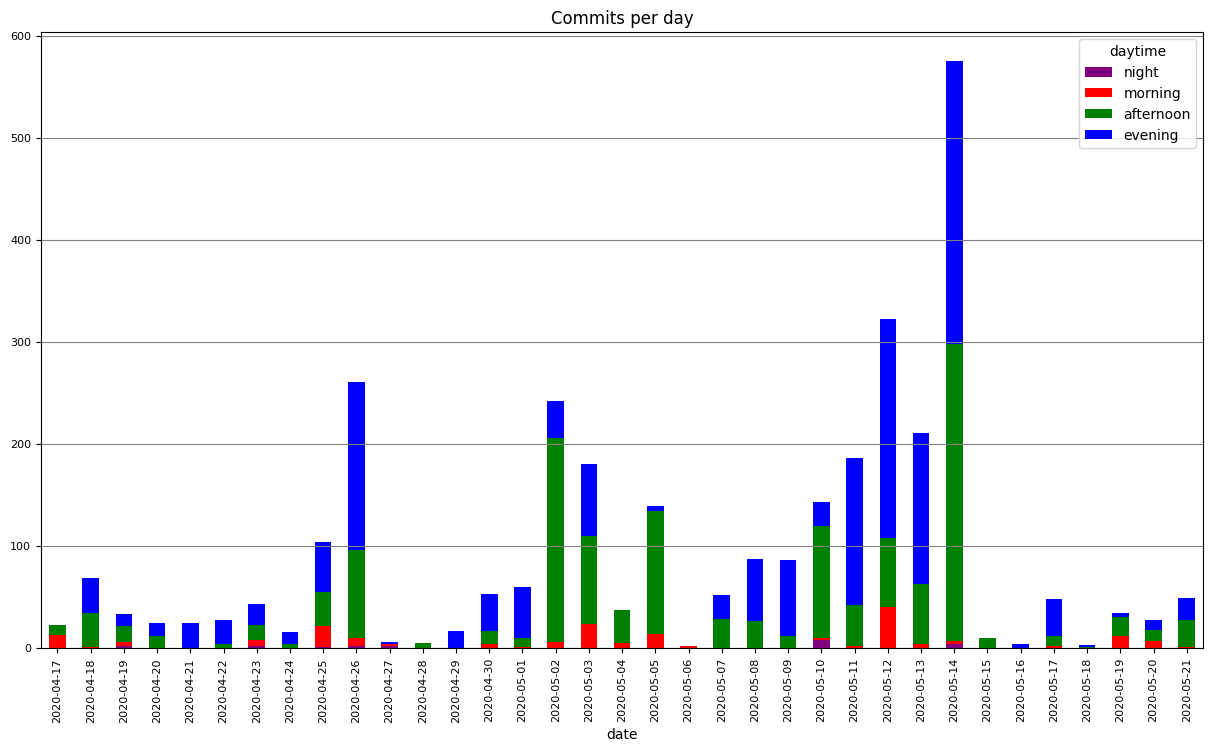

In [7]:
palette = {
    "morning": "red",
    "evening": "blue",
    "afternoon": "green",
    "night": "purple",
}
ax = pivot_df.plot(
    rot=90,
    kind="bar",
    fontsize=8,
    stacked=True,
    color=palette,
    figsize=(15, 8, ),
    title="Commits per day",
)

ax.grid(
    axis='y',
    visible=True,
    color="grey",
    which="major",
    linestyle='-',
)

In [8]:
temp_df= df.drop(columns=["datetime", ]).groupby("daytime", ).count().sort_values(by=["date", ], )
temp_df

,date
daytime,
night,21
morning,184
afternoon,1391
evening,1611


### Когда наши пользователи обычно коммитят: ночью, утром, днём или вечером?

In [14]:
print(f"{temp_df.index[-1]} and {temp_df.index[-2]}.", )

evening and afternoon.


### Какой день имел максимальное число коммитов и при этом вечером коммитов больше, чем днём

In [15]:
print(f"{pivot_df[pivot_df["evening"] > pivot_df["afternoon"]].groupby("date", ).sum().sum(axis=1, ).sort_values().index[-1]}.", )

2020-05-12.


### Закрываем соединение с базой данных.

In [16]:
conn.close()